# Clase 01: ¿Por qué existen las estructuras de datos?

Curso intersemestral de **Estructuras de datos** para Matemáticas Aplicadas.

Idea central de la clase:

> Elegir una estructura de datos es elegir qué operaciones queremos hacer eficientes.

## Objetivos

Al terminar este notebook deberías poder:

- Explicar informalmente qué es una estructura de datos.
- Distinguir problema, representación de datos, algoritmo y resultado.
- Medir tiempos simples con `time.perf_counter`.
- Comparar búsqueda en `list` y `set`.
- Comparar conteo con `dict` y `Counter`.
- Conectar estructuras de datos con interfaces y métodos de Programación Orientada a Objetos.

## 1. Estructuras de datos, versión informal

Una **estructura de datos** es una forma de representar información para que ciertas operaciones sean naturales o eficientes.

Por ejemplo:

- Si quiero conservar orden, una `list` puede ser natural.
- Si quiero preguntar muchas veces si un valor aparece, un `set` puede ser más conveniente.
- Si quiero asociar una llave con un valor, un `dict` es natural.
- Si quiero contar frecuencias, `Counter` ya expresa esa intención.

In [4]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt

candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'clase_01']
raiz = next(
    candidato for candidato in candidatos
    if (candidato / 'src' / 'mediciones.py').exists()
)

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.mediciones import (
    buscar_en_conjunto,
    buscar_en_lista,
    contar_con_counter,
    contar_con_diccionario,
    generar_datos,
    medir_tiempo,
)

print('Listo: imports cargados correctamente.')

Listo: imports cargados correctamente.


## 2. Generar datos

Generaremos una lista de enteros con repeticiones. Las repeticiones nos servirán después para contar frecuencias.

In [5]:
n = 100_000
datos = generar_datos(n)

objetivo_presente = datos[-1]
objetivo_ausente = -1

print(f'Cantidad de datos: {len(datos):,}')
print(f'Primeros 10 datos: {datos[:10]}')
print(f'Objetivo presente: {objetivo_presente}')
print(f'Objetivo ausente: {objetivo_ausente}')

Cantidad de datos: 100,000
Primeros 10 datos: [1824, 409, 4506, 4012, 3657, 2286, 1679, 8935, 1424, 9674]
Objetivo presente: 1917
Objetivo ausente: -1


## 3. Medición básica con `time.perf_counter`

`time.perf_counter` sirve para medir intervalos cortos de tiempo. La idea básica es:

1. Tomar el tiempo inicial.
2. Ejecutar la operación.
3. Tomar el tiempo final.
4. Restar.

In [6]:
inicio = time.perf_counter()
resultado = buscar_en_lista(datos, objetivo_ausente)
fin = time.perf_counter()

print(f'¿Aparece el objetivo? {resultado}')
print(f'Tiempo: {fin - inicio:.6f} segundos')

¿Aparece el objetivo? False
Tiempo: 0.002400 segundos


### Pregunta

Si el valor no aparece en una lista, ¿cuántos elementos necesita revisar Python antes de estar seguro?

## 4. Búsqueda en lista

Una lista conserva orden y repeticiones. Para buscar pertenencia, Python puede necesitar recorrer muchos elementos.

In [7]:
tiempo_lista_presente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_presente),
    repeticiones=10,
)

tiempo_lista_ausente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_ausente),
    repeticiones=10,
)

print(f'Lista, objetivo presente: {tiempo_lista_presente:.6f} segundos')
print(f'Lista, objetivo ausente:  {tiempo_lista_ausente:.6f} segundos')

Lista, objetivo presente: 0.000123 segundos
Lista, objetivo ausente:  0.002080 segundos


## 5. Búsqueda en conjunto

Un conjunto (`set`) está diseñado para preguntas de pertenencia: `x in conjunto`.

Importante: convertir una lista a conjunto también cuesta. Por eso, si vamos a hacer muchas consultas, suele convenir construir el conjunto una vez y reutilizarlo.

In [8]:
conjunto = set(datos)

tiempo_set_presente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_presente),
    repeticiones=10,
)

tiempo_set_ausente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_ausente),
    repeticiones=10,
)

print(f'Conjunto, objetivo presente: {tiempo_set_presente:.8f} segundos')
print(f'Conjunto, objetivo ausente:  {tiempo_set_ausente:.8f} segundos')
print(f'Tamaño de la lista: {len(datos):,}')
print(f'Tamaño del conjunto: {len(conjunto):,}')

Conjunto, objetivo presente: 0.00000192 segundos
Conjunto, objetivo ausente:  0.00000099 segundos
Tamaño de la lista: 100,000
Tamaño del conjunto: 10,000


### Preguntas

1. ¿Por qué el conjunto puede tener menos elementos que la lista? Porque no cuenta los elementos que se repiten
2. ¿Qué información conserva la lista que el conjunto ya no representa de la misma forma? La cantidad de elementos
3. Si solo te importa saber si un valor aparece, ¿qué estructura parece más natural? El conjunto

## 6. Comparar varios tamaños

Ahora repetimos la medición con distintos tamaños. Usaremos un objetivo ausente para forzar el peor caso típico en una lista.

In [9]:
tamanos = [1_000, 10_000, 50_000, 100_000, 200_000]
tiempos_lista = []
tiempos_set = []

for tamano in tamanos:
    muestra = generar_datos(tamano)
    conjunto_muestra = set(muestra)
    ausente = -1

    t_lista = medir_tiempo(lambda: buscar_en_lista(muestra, ausente), repeticiones=8)
    t_set = medir_tiempo(lambda: buscar_en_conjunto(conjunto_muestra, ausente), repeticiones=8)

    tiempos_lista.append(t_lista)
    tiempos_set.append(t_set)

print('tamaño      lista (s)      set (s)')
for tamano, t_lista, t_set in zip(tamanos, tiempos_lista, tiempos_set):
    print(f'{tamano:>7,}   {t_lista:>11.8f}   {t_set:>11.8f}')

tamaño      lista (s)      set (s)
  1,000    0.00003054    0.00000172
 10,000    0.00038202    0.00000186
 50,000    0.00095904    0.00000172
100,000    0.00185341    0.00000164
200,000    0.00453730    0.00000156


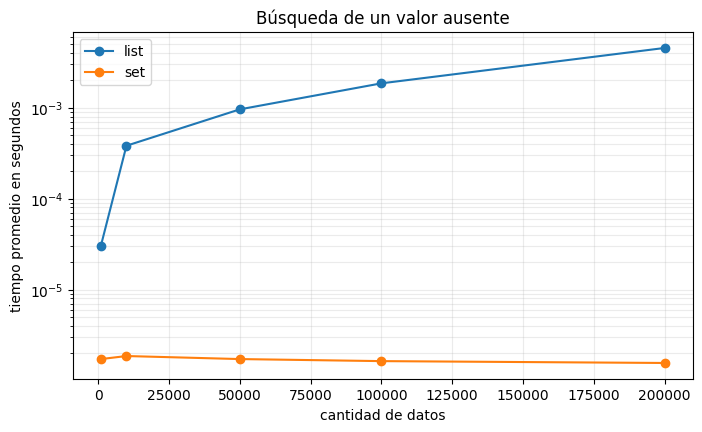

In [10]:
plt.figure(figsize=(8, 4.5))
plt.plot(tamanos, tiempos_lista, marker='o', label='list')
plt.plot(tamanos, tiempos_set, marker='o', label='set')
plt.yscale('log')
plt.xlabel('cantidad de datos')
plt.ylabel('tiempo promedio en segundos')
plt.title('Búsqueda de un valor ausente')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show()

### Interpretación

Escribe una conclusión breve:

- ¿Qué curva crece más rápido? La de lista
- ¿Qué operación queríamos hacer eficiente? Busqueda de un valor ausente
- ¿Qué costo pagamos antes de poder buscar en un conjunto? 0.00003054 en lista y 0.00000172 en set

## 7. Conteo con diccionario

Para contar frecuencias, una representación natural es:

$$\text{valor} \mapsto \text{frecuencia}$$

En Python, esto se puede representar con un diccionario.

In [11]:
conteos_dict = contar_con_diccionario(datos)

print(f'Valores distintos: {len(conteos_dict):,}')
print('Primeros 10 pares valor -> frecuencia:')
for valor, frecuencia in list(conteos_dict.items())[:10]:
    print(f'{valor:>5} -> {frecuencia}')

Valores distintos: 10,000
Primeros 10 pares valor -> frecuencia:
 1824 -> 8
  409 -> 8
 4506 -> 14
 4012 -> 9
 3657 -> 15
 2286 -> 15
 1679 -> 8
 8935 -> 4
 1424 -> 11
 9674 -> 10


## 8. Conteo con `Counter`

`Counter` es una clase de la biblioteca estándar diseñada para conteos. Es útil cuando el problema ya es claramente un problema de frecuencias.

In [12]:
conteos_counter = contar_con_counter(datos)

print('Los 10 valores más frecuentes:')
for valor, frecuencia in conteos_counter.most_common(10):
    print(f'{valor:>5} -> {frecuencia}')

assert dict(conteos_counter) == conteos_dict
print('El diccionario y Counter contienen las mismas frecuencias.')

Los 10 valores más frecuentes:
 7289 -> 24
 7779 -> 23
 4009 -> 22
 9697 -> 21
 2001 -> 21
  897 -> 21
 9376 -> 21
 5269 -> 21
 3519 -> 21
  848 -> 21
El diccionario y Counter contienen las mismas frecuencias.


## 9. Comparar `dict` y `Counter`

Ambas opciones representan conteos. La diferencia no es solo de tiempo: también importa la claridad de la intención.

In [13]:
tiempo_dict = medir_tiempo(lambda: contar_con_diccionario(datos), repeticiones=5)
tiempo_counter = medir_tiempo(lambda: contar_con_counter(datos), repeticiones=5)

print(f'Diccionario manual: {tiempo_dict:.6f} segundos')
print(f'Counter:            {tiempo_counter:.6f} segundos')

Diccionario manual: 0.043693 segundos
Counter:            0.023060 segundos


### Preguntas

1. ¿Qué hace explícito el diccionario manual? Las relaciones
2. ¿Qué hace más cómodo `Counter`? genera un menor gasto de tiempo
3. ¿Cuál usarías en una librería educativa? ¿Por qué? el diccionario manual porque es explícito en sus relaciones

## 10. Problema, representación, algoritmo y resultado

Completa mentalmente o por escrito esta tabla para un problema propio de Matemáticas Aplicadas.

| Elemento | Ejemplo: conteo de datos | Tu ejemplo |
| --- | --- | --- |
| Problema | Encontrar frecuencias |Encntrar las paginas mas frecuentadas en un historial |
| Representación | Diccionario valor -> frecuencia |Diccionario valor -> frecuencia |
| Algoritmo | Recorrer datos y actualizar conteos |Recorrer datos y actualizar conteos |
| Resultado | Tabla de frecuencias |Tabla de frecuencias |
| Operación eficiente | Actualizar o consultar una frecuencia | Actualizar o consultar una frecuencia|

## 11. Ejercicio guiado

Cambia `n_ejercicio` y observa cómo cambian los tiempos. Mantén el objetivo ausente para comparar el peor caso típico de búsqueda en lista.

In [14]:
n_ejercicio = 50_000
datos_ejercicio = generar_datos(n_ejercicio)
conjunto_ejercicio = set(datos_ejercicio)
objetivo = -1

tiempo_lista = medir_tiempo(lambda: buscar_en_lista(datos_ejercicio, objetivo), repeticiones=10)
tiempo_set = medir_tiempo(lambda: buscar_en_conjunto(conjunto_ejercicio, objetivo), repeticiones=10)

print(f'n = {n_ejercicio:,}')
print(f'lista: {tiempo_lista:.8f} segundos')
print(f'set:   {tiempo_set:.8f} segundos')

n = 50,000
lista: 0.00113938 segundos
set:   0.00000119 segundos


## 12. Conexión con Programación Orientada a Objetos

En POO ya trabajaste con clases, atributos y métodos. Una estructura de datos también se puede pensar como un objeto con una **interfaz**:

- Qué operaciones ofrece.
- Qué promete cada operación.
- Qué detalles internos quedan ocultos.

Por ejemplo, una pila puede ofrecer `push`, `pop`, `peek` e `is_empty`, aunque internamente pueda guardarse de distintas formas.

## 13. Reflexión final

Responde con tus palabras:

1. ¿Por qué existen las estructuras de datos? Para optimmizar la solucion de problemas al momento de manejar detos.
2. ¿Qué significa que una operación sea natural para una estructura? Que es lo màs intuitivo 
3. ¿Qué estructura usarías para representar amistades en una red social? un diccionario 
4. ¿Qué estructura usarías para representar rutas en una ciudad? un diccionario también 
5. ¿Cómo se conecta todo esto con el proyecto colaborativo del curso? Podemos usar estás herramientas para ello.

## 14. Reto opcional

Medir solo la búsqueda en un conjunto puede esconder el costo de construirlo. En este reto medimos el costo total de:

1. Convertir la lista a conjunto.
2. Hacer muchas consultas de pertenencia.

Pregunta: ¿a partir de cuántas consultas empieza a convenir construir el conjunto?  a paritr de 100

In [16]:
def medir_muchas_consultas_en_lista(datos, consultas):
    inicio = time.perf_counter()
    for objetivo in consultas:
        objetivo in datos
    return time.perf_counter() - inicio


def medir_muchas_consultas_en_set(datos, consultas):
    inicio = time.perf_counter()
    conjunto = set(datos)
    for objetivo in consultas:
        objetivo in conjunto
    return time.perf_counter() - inicio


datos_reto = generar_datos(30_000)

for cantidad_consultas in [1, 10, 100, 500, 1_000]:
    consultas = [-1 - i for i in range(cantidad_consultas)]
    t_lista = medir_muchas_consultas_en_lista(datos_reto, consultas)
    t_set = medir_muchas_consultas_en_set(datos_reto, consultas)
    print(f'{cantidad_consultas:>5,} consultas | lista: {t_lista:.5f}s | set total: {t_set:.5f}s')

    1 consultas | lista: 0.00078s | set total: 0.00204s
   10 consultas | lista: 0.00961s | set total: 0.00359s
  100 consultas | lista: 0.07134s | set total: 0.00155s
  500 consultas | lista: 0.34947s | set total: 0.00171s
1,000 consultas | lista: 0.67454s | set total: 0.00163s
